In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

In [2]:
df = sns.load_dataset('diamonds')

# Zapoznanie ze zbiorem danych

In [3]:
df.head(10)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
5,0.24,Very Good,J,VVS2,62.8,57.0,336,3.94,3.96,2.48
6,0.24,Very Good,I,VVS1,62.3,57.0,336,3.95,3.98,2.47
7,0.26,Very Good,H,SI1,61.9,55.0,337,4.07,4.11,2.53
8,0.22,Fair,E,VS2,65.1,61.0,337,3.87,3.78,2.49
9,0.23,Very Good,H,VS1,59.4,61.0,338,4.00,4.05,2.39


In [4]:
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
carat,53940.0,0.797940,0.474011,0.2,0.40,0.70,1.04,5.01
depth,53940.0,61.749405,1.432621,43.0,61.00,61.80,62.50,79.00
table,53940.0,57.457184,2.234491,43.0,56.00,57.00,59.00,95.00
price,53940.0,3932.799722,3989.439738,326.0,950.00,2401.00,5324.25,18823.00
x,53940.0,5.731157,1.121761,0.0,4.71,5.70,6.54,10.74
y,53940.0,5.734526,1.142135,0.0,4.72,5.71,6.54,58.90
z,53940.0,3.538734,0.705699,0.0,2.91,3.53,4.04,31.80


In [6]:
df.describe(include='all')

,carat,cut,color,clarity,depth,table,price,x,y,z
count,53940.000000,53940,53940,53940,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
unique,NaN,5,7,8,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Ideal,G,SI1,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,21551,11292,13065,NaN,NaN,NaN,NaN,NaN,NaN
mean,0.797940,NaN,NaN,NaN,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,NaN,NaN,NaN,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,NaN,NaN,NaN,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,NaN,NaN,NaN,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,NaN,NaN,NaN,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,NaN,NaN,NaN,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000


In [7]:
df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [8]:
df.shape

(53940, 10)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [10]:
df.dtypes

carat       float64
cut        category
color      category
clarity    category
depth       float64
table       float64
price         int64
x           float64
y           float64
z           float64
dtype: object

In [11]:
df.columns.tolist()

['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']

# Wstępna analiza zbioru danych

## Na wykresie punktowym widać tendencję wzrostu ceny w zależności diamentu z większą ilością karatów (0,2 g) oraz ich czystością. Nawet mniejsze diamenty mogą być więcej warte jeśli mają czystość wyższą niż te większe, ale o znacznie mniejszej czystości. Na wykresie diamenty o czystości IF mimo, że mogą mieć około jednego karatu to ceną dorównują diamentom z 4-5 karatami w przypadku gdzie one mają bardzo niską czystość/jakość diamentu l1.

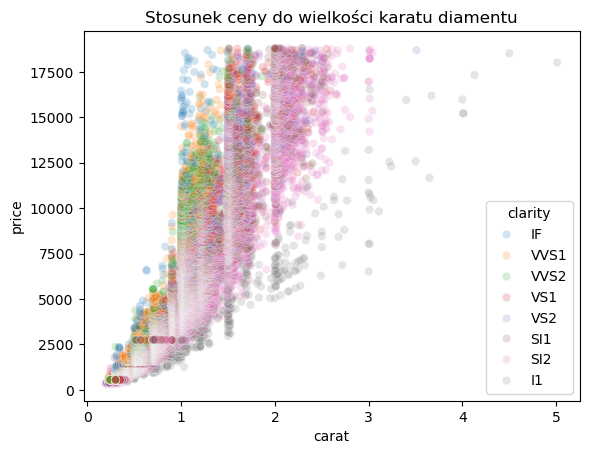

In [12]:
sns.scatterplot(x=df['carat'], y=df['price'], hue=df['clarity'], alpha=0.2)
plt.title('Stosunek ceny do wielkości karatu diamentu')
plt.show()

In [13]:
df['clarity'].unique()

['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF']
Categories (8, object): ['IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1']

# Boxplot: cut i price (szlif i cena)

## Poniższy boxplot przedstawia zależność jakości szlifu od ceny. Największy rozrzut cen ma szlif Premium, a najmniejszy Fair. Najniższą medianę ma szlif Ideal, bo przyczyną tego może być waga lub rozmiar diamentu. Mediana reszty szlifów jest na podobnym poziomie, co świadczy o różnorodności diamentów i wpływu innych cech na cenę. W lepszym jakości szlifie widać więcej outlierów, a w przypadku Fair widać widocznie ich mniejszą liczbę niż w innych przypadkach, więc ekstremalnie drogich diamentów o najgorszej jakości (Fair) jest mniej. Ten wykres pudełkowy pokazuje, że jakość szlifu nie determinuje bardzo ceny diamentu.

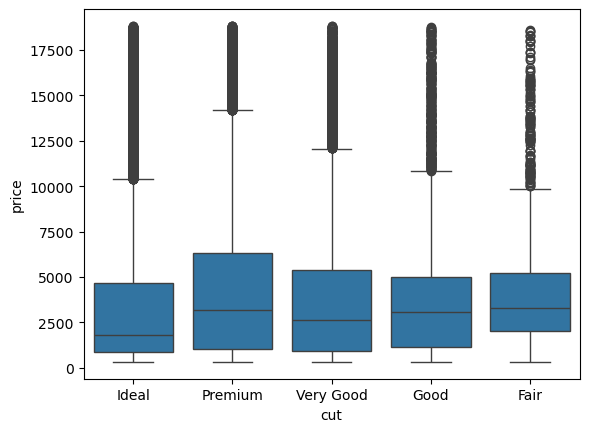

In [14]:
sns.boxplot(x=df['cut'], y=df['price'])
plt.show()

# Boxplot: color i price (kolor i cena)

## Skala kolorów diamentów mówi, że im niższe zabarwienie tym jest lepsze, a większe zabarwienie diamentu to niższa jakość, czyli D -> E -> F -> G -> H -> I -> J (https://e-diamenty.pl/poradnik/barwa). Boxplot pokazuje, że wyższe ceny osiąga barwa J dla Q3 (górna część pudełka jako 75% wszystkich wartości). Mediany ceny diamentów D, E, F, G są podobne, zaś H, I, J wyższe. Z wykresu można byłoby dojść do błędnych wniosków, że niższa jakoś koloru kosztuje więcej, chociaż skala kolorów diamentów mówi, że bardziej oczekiwane są diamenty bezbarwne. Wniosek z tego wykresu jest taki, że inne czynniki bardziej determinują cenę niż kolor diamentu, np. karat (waga) lub jego rozmiar.

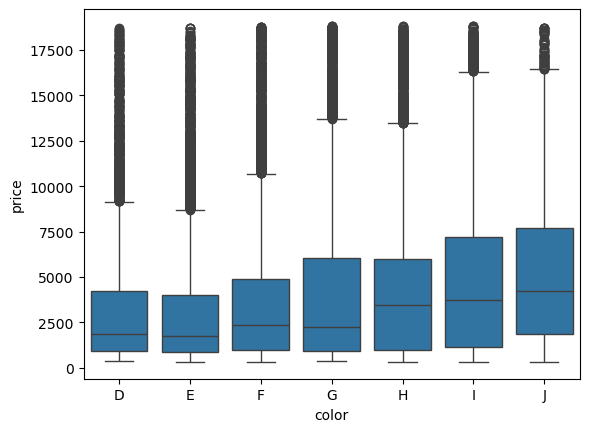

In [15]:
sns.boxplot(x=df['color'], y=df['price'])
plt.show()

# Encoding cech kategorialnych

## Encoding cech kategorialnych jest potrzebny, ponieważ modele m.in. Regresja Liniowa oraz Random Forest nie uczą się na ciągach znaków, ale na wartościach numerycznych. Jeśli wartości nie są określone w sposób porządkowy to metoda one-hot jest najlepsza, np. w przpadku kolorów ('color'). W przypadku cech takich jak 'cut' oraz 'clarity' użyłem metodę one-hot, chociaż możliwe jest także użycie EncodingLabel, która przypisuje numer zastępujący odpowiednią wartość powtarzalną kolumny.

In [16]:
df_one_hot = pd.get_dummies(df, columns=['cut', 'color', 'clarity'], drop_first=True)

In [17]:
df_one_hot

,carat,depth,table,price,x,y,z,cut_Premium,cut_Very Good,cut_Good,...,color_H,color_I,color_J,clarity_VVS1,clarity_VVS2,clarity_VS1,clarity_VS2,clarity_SI1,clarity_SI2,clarity_I1
0,0.23,61.5,55.0,326,3.95,3.98,2.43,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,0.21,59.8,61.0,326,3.89,3.84,2.31,True,False,False,...,False,False,False,False,False,False,False,True,False,False
2,0.23,56.9,65.0,327,4.05,4.07,2.31,False,False,True,...,False,False,False,False,False,True,False,False,False,False
3,0.29,62.4,58.0,334,4.20,4.23,2.63,True,False,False,...,False,True,False,False,False,False,True,False,False,False
4,0.31,63.3,58.0,335,4.34,4.35,2.75,False,False,True,...,False,False,True,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,0.72,60.8,57.0,2757,5.75,5.76,3.50,False,False,False,...,False,False,False,False,False,False,False,True,False,False
53936,0.72,63.1,55.0,2757,5.69,5.75,3.61,False,False,True,...,False,False,False,False,False,False,False,True,False,False
53937,0.70,62.8,60.0,2757,5.66,5.68,3.56,False,True,False,...,False,False,False,False,False,False,False,True,False,False
53938,0.86,61.0,58.0,2757,6.15,6.12,3.74,True,False,False,...,True,False,False,False,False,False,False,False,True,False


# Podział na dane treningowe i testowe

## Poniżej dzielę odpowiednio dane na X, czyli na kolumny, które mają posłużyć do wywnioskowania usuniętej kolumny, zaś y to kolumna jaką model ma nauczyć się zgadywać ('price'), czyli cenę diamentu. Regresja liniowa potrzebuje danych numerycznych, które są przeskalowane, ponieważ oblicza ona wagi na podstawie cech, więc ich wielkość nie może zdominować innych cech przez samą liczbę, a co najwyżej ważność cech. Random Forest działa inaczej, więc nie potrzebuje przeskalowanych cech. Random Forest działa na zasadzie opcji wyboru lub na podobę drzew decyzyjnych, więc nie oblicza wag jak regresja liniowa.

In [18]:
X = df_one_hot.drop('price', axis=1)
y = df_one_hot['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

columns_to_standardize = X.columns.tolist()
scaler = StandardScaler()
X_train_scaled[columns_to_standardize] = scaler.fit_transform(X_train[columns_to_standardize])
X_test_scaled[columns_to_standardize] = scaler.transform(X_test[columns_to_standardize])

# Modele: Regresja Liniowa oraz Random Forest

## Oba modele będą testowane za pomocą metryk: MAE, RMSE oraz R^2 w celu sprawdzenia ich skuteczności. Celem modeli nie jest klasyfikacja, więc nie mogą korzystać z accuracy_score, confusion_matrix. Metryki dają odpowiednie informacje o modelu:
## 1. MAE - jest to średnia wartość jaką model może pomylić się czy zgadywaniu (w tym przypadku ceny).
## 2. RMSE - określa katastrofalne błędy, czyli duże odchyły w zgadywaniu poprawnej wartości (w tym przypadku ceny). Nawet jedna duża pomyłka może odbić się na tej metryce.
## 3. R^2 - metryka, która porównuje średnie błędy modelu z przypadkiem, gdyby zamiast model zgadywał wartość to wartośc byłaby po prostu średnią (w tym przypadku ceną) wszystkich wartości. Jeśli model jest blisko 1 to jest on dobrym modelem, zaś jeśli jest ujemny to model jest zły (nie nadaje się).

## Regresja liniowa

### Model Regresji Liniowej myli się średnio w zgadywaniu ceny o 737 (MAE). RMSE (1135) > MAE (737), więc model popełnia kilka katastrofalnych wpadek, ale R^2 = 0,918, więc jest on dość dobry do używania.

In [20]:
model_lin_reg = LinearRegression()
model_lin_reg.fit(X_train_scaled, y_train)

LinearRegression()

In [21]:
y_pred_lin_reg = model_lin_reg.predict(X_test_scaled)

print('MAE (średni błąd bezwzględny):', mean_absolute_error(y_test, y_pred_lin_reg))
print('RMSE (pierwiastek błędu średniokwadratowego):', np.sqrt(mean_squared_error(y_test, y_pred_lin_reg)))
print('R^2 (współczynnik determinacji)', r2_score(y_test, y_pred_lin_reg))

MAE (średni błąd bezwzględny): 737.1513665933278
RMSE (pierwiastek błędu średniokwadratowego): 1135.2116445190625
R^2 (współczynnik determinacji) 0.9189331350419387


## Random Forest

### Model Random Forest myli się średnio w zgadywaniu ceny o 277 (MAE). RMSE (556,67) > MAE (277), więc model popełnia kilka katastrofalnych wpadek, ale R^2 =0,98, więc jest on bardzo skutecznym modelem. Random Forest jak widać dał lepsze wyniki, myli się o mniejszą wartość ceny, popełnia średnio mniej katastrofalnych błędów oraz posiada wyższą skuteczność, a więc Random Forest w przypadku tych danych działa lepiej niż Regresja Liniowa!

In [22]:
model_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
model_regressor.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [23]:
y_pred_regressor = model_regressor.predict(X_test)

print('MAE (średni błąd bezwzględny):', mean_absolute_error(y_test, y_pred_regressor))
print('RMSE (pierwiastek błędu średniokwadratowego):', np.sqrt(mean_squared_error(y_test, y_pred_regressor)))
print('R^2 (współczynnik determinacji)', r2_score(y_test, y_pred_regressor))

MAE (średni błąd bezwzględny): 277.04694856056994
RMSE (pierwiastek błędu średniokwadratowego): 556.6702088618044
R^2 (współczynnik determinacji) 0.9805066866741659


# Wykres pokazuje, że do treningu modelu najbardziej przyczyniają się cechy takie jak: carat (0.613) oraz y (0.273) - jeden z wymiarów. Reszta cech ma mniejszy wpływ na trening modelu, chociaż występuje w danych modelu redundancja, czyli pewne cechy (carat, x, y, z) niosą podobne informacje, więc nie są potrzebne. Gdyby usunąć jedną z nich to ich ważność może ulec zmianie. Uwzględniając również redundancję to największy wpływ na wielkość ceny ma waga oraz wymiar diamentu! Redundancję potwierdza wysoka korelacja pomiędzy cechami: carat, x, y, z.

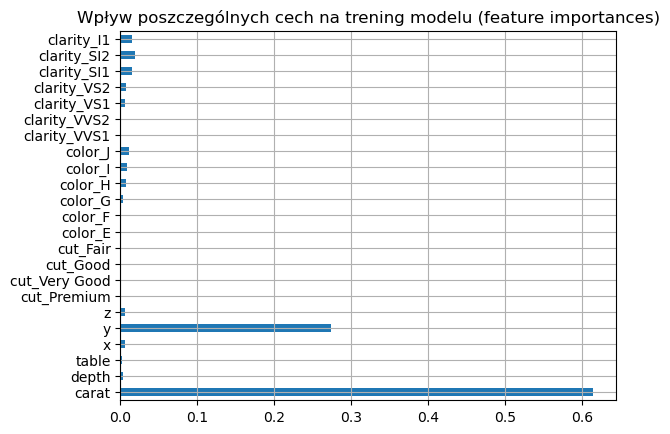

In [24]:
forest_importances = pd.Series(model_regressor.feature_importances_, index=X.columns)

fig, ax = plt.subplots()

forest_importances.plot.barh()
ax.set_title('Wpływ poszczególnych cech na trening modelu (feature importances)')
ax.grid()
plt.show()

In [25]:
model_regressor.feature_importances_

array([6.13474180e-01, 3.43006784e-03, 2.52990519e-03, 5.73903203e-03,
       2.72796677e-01, 5.43329669e-03, 4.75326759e-04, 3.84310126e-04,
       2.69657887e-04, 1.57409880e-04, 1.06258858e-03, 1.09632351e-03,
       3.17066032e-03, 6.80927568e-03, 8.22472765e-03, 1.11902169e-02,
       5.92137717e-04, 1.15230297e-03, 5.75488662e-03, 7.19391898e-03,
       1.45401352e-02, 1.94936895e-02, 1.50292727e-02])

In [26]:
X.columns

Index(['carat', 'depth', 'table', 'x', 'y', 'z', 'cut_Premium',
       'cut_Very Good', 'cut_Good', 'cut_Fair', 'color_E', 'color_F',
       'color_G', 'color_H', 'color_I', 'color_J', 'clarity_VVS1',
       'clarity_VVS2', 'clarity_VS1', 'clarity_VS2', 'clarity_SI1',
       'clarity_SI2', 'clarity_I1'],
      dtype='object')

In [27]:
df[['carat', 'x', 'y', 'z']].corr()

,carat,x,y,z
carat,1.000000,0.975094,0.951722,0.953387
x,0.975094,1.000000,0.974701,0.970772
y,0.951722,0.974701,1.000000,0.952006
z,0.953387,0.970772,0.952006,1.000000


# Na wykresach można zauważyć skuteczność obu modeli. Wcześniejsze metryki określiły większą skuteczność modelu Random Forest (98%) i niższą skuteczność Regresji Liniowej (91,8%), a wykres potwierdza to stwierdzenie. Tak jak widać na wykresie Random Forest punkty znajdują się znacznie bliżej linii czerwonej, a więc są bliżej prawdziwego wyniku (ceny), a w regresji liniowej mimo, że na wykresie z Regresją Liniową punkty są bliskie czerwonej linii to jednak punkty układają się trochę dalej niż w Random Forest. Wykresy te potwierdzają obliczone metryki i skuteczność modelu!

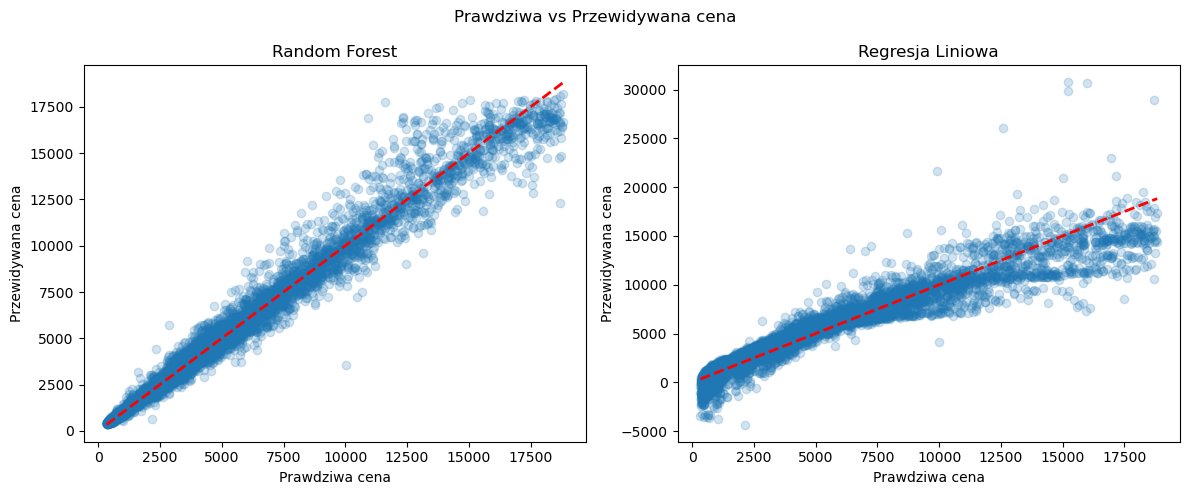

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

fig.suptitle('Prawdziwa vs Przewidywana cena')

ax[0].scatter(y_test, y_pred_regressor, alpha=0.2)
ax[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
ax[0].set_xlabel('Prawdziwa cena')
ax[0].set_ylabel('Przewidywana cena')
ax[0].set_title('Random Forest')

ax[1].scatter(y_test, y_pred_lin_reg, alpha=0.2)
ax[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
ax[1].set_xlabel('Prawdziwa cena')
ax[1].set_ylabel('Przewidywana cena')
ax[1].set_title('Regresja Liniowa')

plt.tight_layout()
plt.show()